In [1]:
import numpy as np
import matplotlib.pyplot as plt
from robot import open_chain, build_numeric_chain, \
    plot_chain, equilateral_triangle, solve_closure, \
    plot_robot

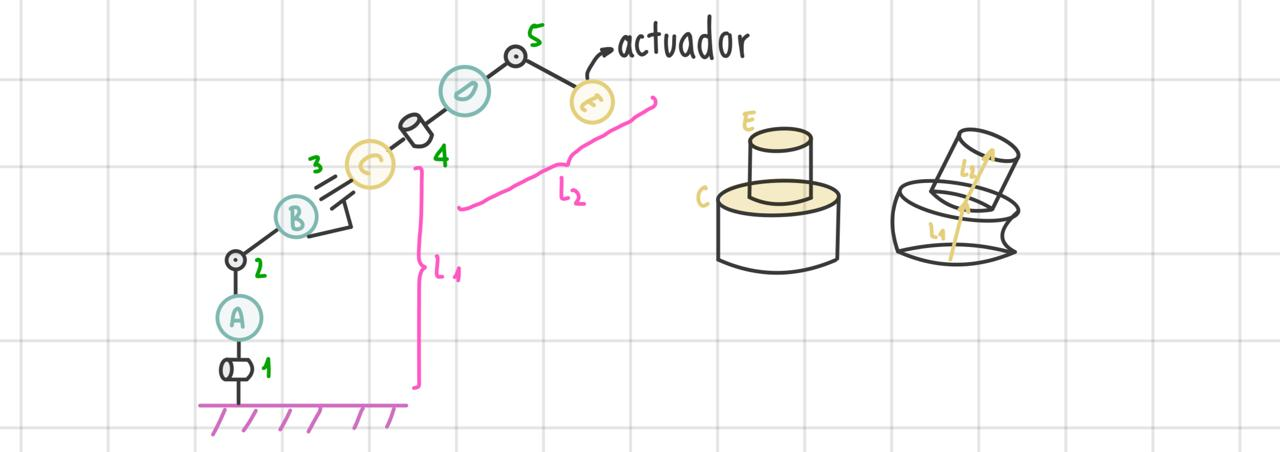

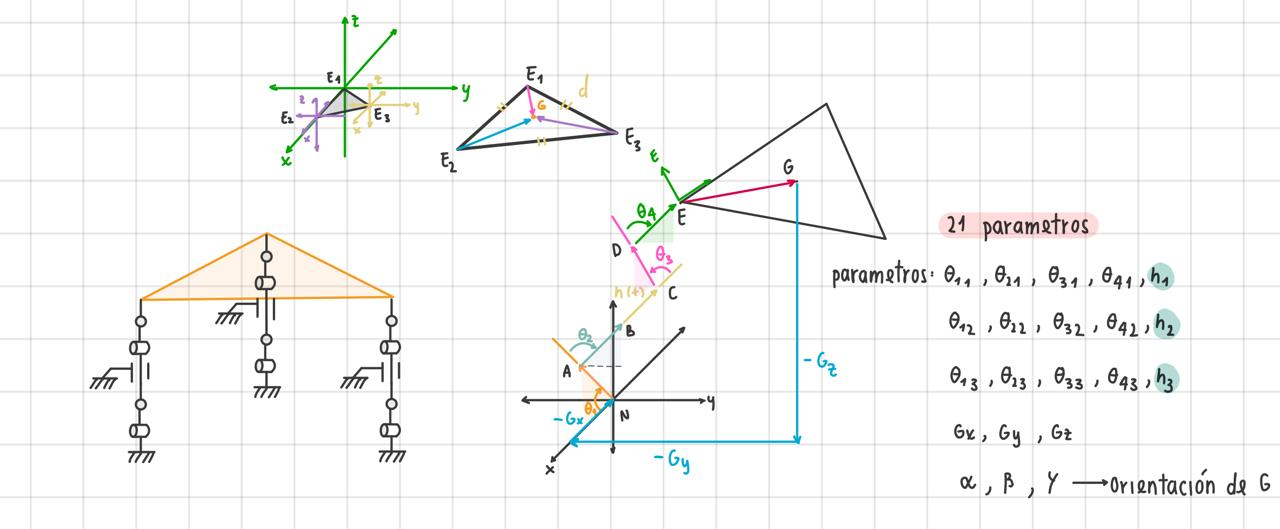

Ecuaciones de Loop de vectores

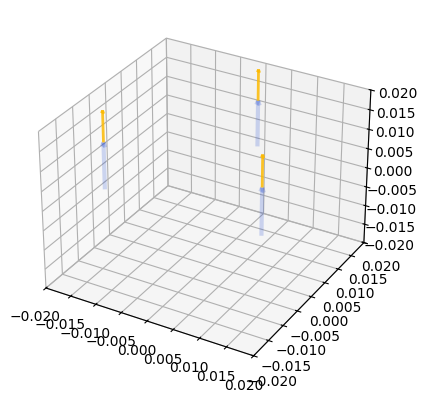

In [2]:
base_vertices=equilateral_triangle()
chain1=open_chain('1',Ox=base_vertices[0,0],Oy=base_vertices[0,1])
chain1_numeric=build_numeric_chain(chain1)
chain2=open_chain('2',Ox=base_vertices[1,0],Oy=base_vertices[1,1])
chain2_numeric=build_numeric_chain(chain2)
chain3=open_chain('3',Ox=base_vertices[2,0],Oy=base_vertices[2,1])
chain3_numeric=build_numeric_chain(chain3)
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

plot_chain(ax,chain1_numeric,[0,0,0,0,0])
plot_chain(ax,chain2_numeric,[0,0,0,0,0])
plot_chain(ax,chain3_numeric,[0,0,0,0,0])

`gtol` termination condition is satisfied.
Function evaluations 32, initial cost 1.3647e-05, final cost 1.6120e-20, first-order optimality 7.70e-13.

Converged : True
Max resid : 1.36e-10
  Chain 1 angles [deg]: [-0.02354701  0.03693503  0.02354701 -0.03693503]
  Chain 2 angles [deg]: [-0.02354703  0.03689713  0.02354703 -0.03689714]
  Chain 3 angles [deg]: [-0.02357983  0.03691606  0.02357982 -0.03691607]
  G = [-4.93396723e-03 -7.73168316e-03  1.99999965e+01] mm


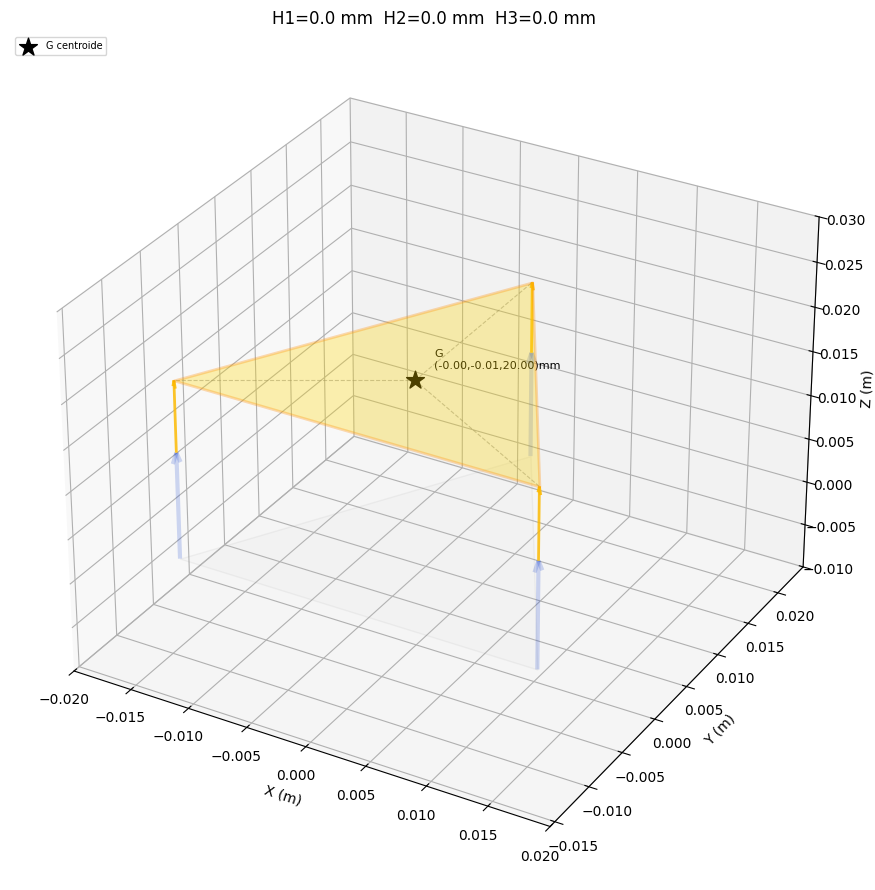

(<Figure size 1300x900 with 1 Axes>,
 <Axes3D: title={'center': 'H1=0.0 mm  H2=0.0 mm  H3=0.0 mm'}, xlabel='X (m)', ylabel='Y (m)', zlabel='Z (m)'>)

In [3]:
H = [0.0, 0.0, 0.0]          # prismatic actuator displacements [m]
numeric_chains = [chain1_numeric, chain2_numeric, chain3_numeric]
sol = solve_closure(H, numeric_chains, verbose=1)

print(f"\nConverged : {sol['result'].success}")
print(f"Max resid : {np.max(np.abs(sol['result'].fun)):.2e}")
for i in range(3):
    print(f"  Chain {i+1} angles [deg]: {np.degrees(sol['angles'][i])}")
print(f"  G = {sol['G'] * 1e3} mm")


qpos=np.hstack([sol['angles'],np.array([H]).T])

plot_robot(numeric_chains,qpos.tolist())

`gtol` termination condition is satisfied.
Function evaluations 7, initial cost 2.5506e-07, final cost 8.7890e-23, first-order optimality 7.33e-13.

Asymmetric case  H = [2. 8. 0.] mm
Converged : True
Max resid : 1.22e-11
  Chain 1 angles [deg]: [7.14506915 2.45105065 4.35450449 8.61624911]
  Chain 2 angles [deg]: [9.24929916 4.73581177 2.25399322 6.32806874]
  Chain 3 angles [deg]: [8.91040405 4.11762841 2.59188229 6.94680255]
  G = [ 2.8153753  -2.0745707  16.25036957] mm


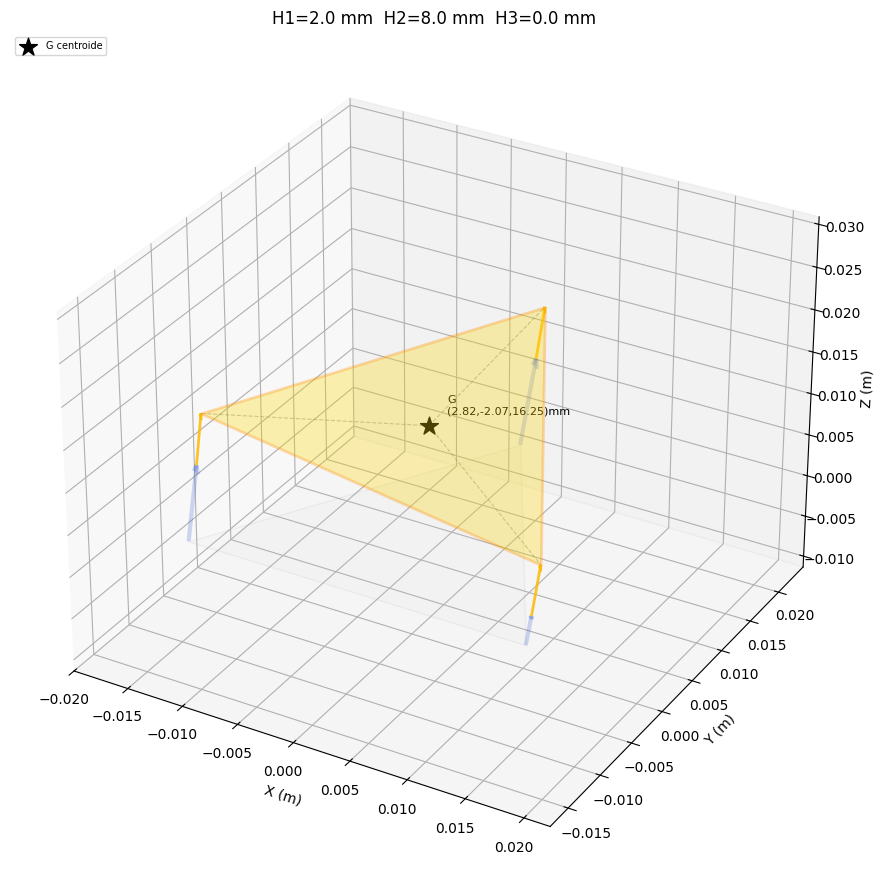

(<Figure size 1300x900 with 1 Axes>,
 <Axes3D: title={'center': 'H1=2.0 mm  H2=8.0 mm  H3=0.0 mm'}, xlabel='X (m)', ylabel='Y (m)', zlabel='Z (m)'>)

In [5]:

# --- Caso asimetrico ---
H = [2e-3, 8e-3, 0.0]     
sol = solve_closure(H, numeric_chains, verbose=1)

print(f"\nAsymmetric case  H = {np.array(H)*1e3} mm")
print(f"Converged : {sol['result'].success}")
print(f"Max resid : {np.max(np.abs(sol['result'].fun)):.2e}")
for i in range(3):
    print(f"  Chain {i+1} angles [deg]: {np.degrees(sol['angles'][i])}")
print(f"  G = {sol['G'] * 1e3} mm")

qpos=np.hstack([sol['angles'],np.array([H]).T])
plot_robot(numeric_chains,qpos.tolist())